## Importación de Librerías

In [70]:
from mpl_toolkits.mplot3d import Axes3D
from scipy.cluster.hierarchy import cophenet
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sb

%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')

# Agrupación de los Clientes

## Visualización de los datos

### Se carga la base de datos

In [71]:
df = pd.read_csv(r"mallCustomers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income,Spending Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Distribución de los datos

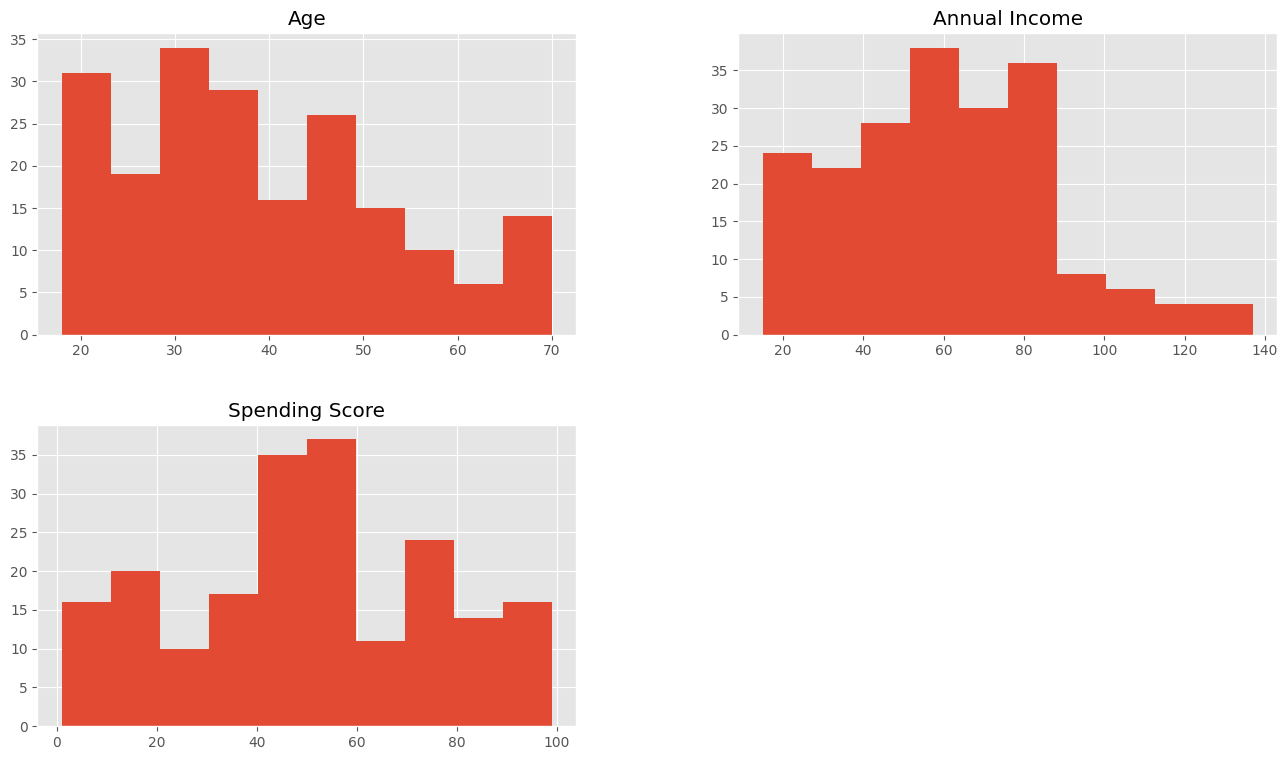

In [72]:
df.drop('CustomerID', axis = 1).hist()
plt.show()

# Tratamiento de datos

### Quitar columna ID

In [73]:
df = df.drop('CustomerID', axis = 1)

### Quitar columna género (Para separa para el apartado 'c') 

In [74]:
df = df.drop('Genre', axis = 1)

### Comprobación de outlayers

Text(0.5, 1.0, 'Violinplot variables')

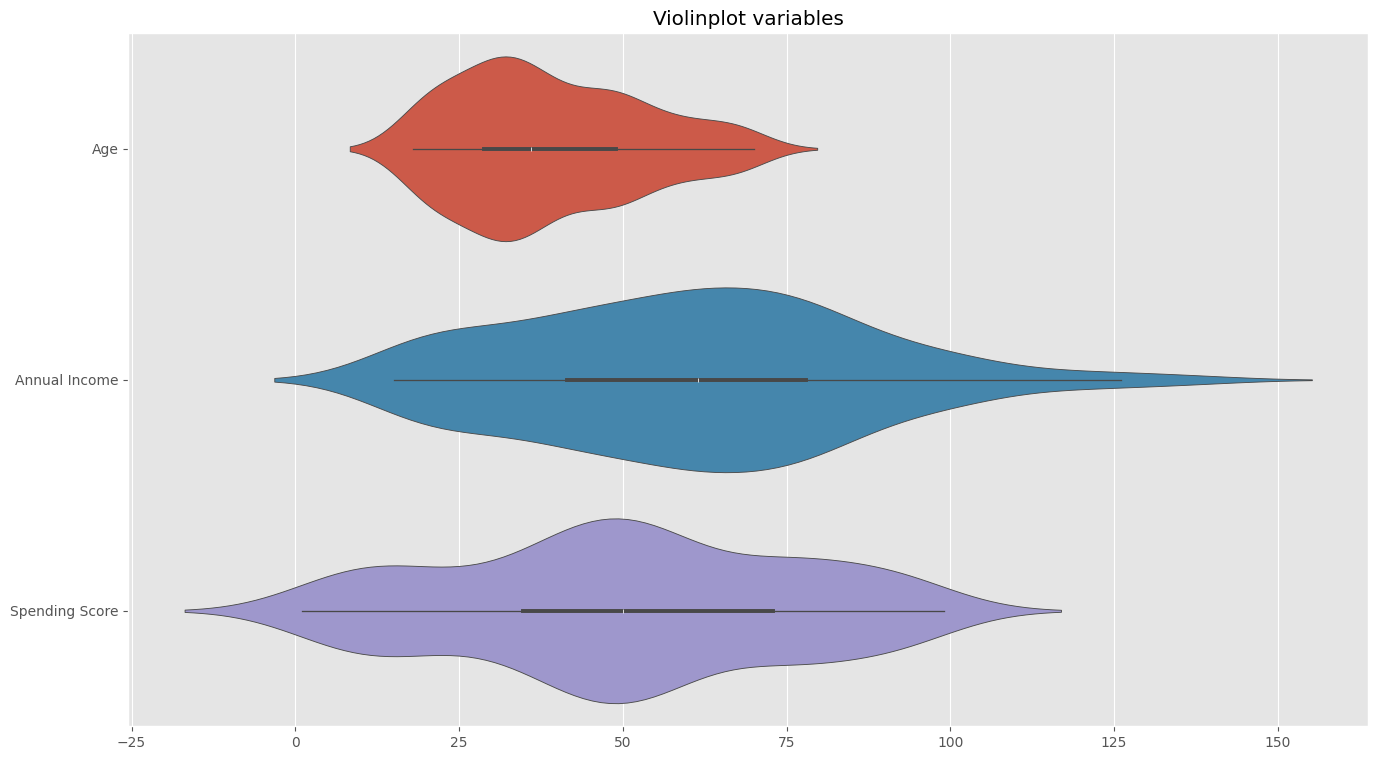

In [75]:
sb.violinplot(data=df, orient='h').set_title("Violinplot variables")

### Eliminación de outlayers

In [76]:
df = df[df['Annual Income'] <= 135]

### Visualización de los datos

In [77]:
df.head()

,Age,Annual Income,Spending Score
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


### Estandarización de los datos

In [78]:
df_mean = df.mean()
df_std = df.std()
df = (df - df_mean) / df_std
df.head()

,Age,Annual Income,Spending Score
0,-1.421809,-1.774673,-0.434887
1,-1.279124,-1.774673,1.196381
2,-1.350467,-1.735049,-1.716597
3,-1.136439,-1.735049,1.041022
4,-0.565697,-1.695425,-0.396047


## Resultados

In [79]:
df.head()

,Age,Annual Income,Spending Score
0,-1.421809,-1.774673,-0.434887
1,-1.279124,-1.774673,1.196381
2,-1.350467,-1.735049,-1.716597
3,-1.136439,-1.735049,1.041022
4,-0.565697,-1.695425,-0.396047


# Agrupamiento de datos

### Visualización de los datos

In [80]:
fig = px.scatter_3d(df, x = 'Age', y = 'Annual Income', z = 'Spending Score')
fig.show()

## K-means

### Se define K-menas

In [81]:
Nc = range(1, 20)
kmeans = [KMeans(n_clusters = i) for i in Nc]
kmeans
score = [kmeans[i].fit(df).score(df) for i in range(len(kmeans))]
score

[-590.9999999999998,
 -445.49637239250035,
 -351.0100068061952,
 -201.67825481207217,
 -163.37913561764802,
 -128.48847431104713,
 -119.29436481255341,
 -99.5325086595127,
 -92.43257703657225,
 -78.57605381363265,
 -75.51204226312264,
 -69.96246386784482,
 -68.11925431235211,
 -58.783189211679,
 -58.68786032609231,
 -55.744861463780154,
 -54.4821383366321,
 -51.113173004830365,
 -47.43644310748672]

### Muestra de gráfica para ver el codo

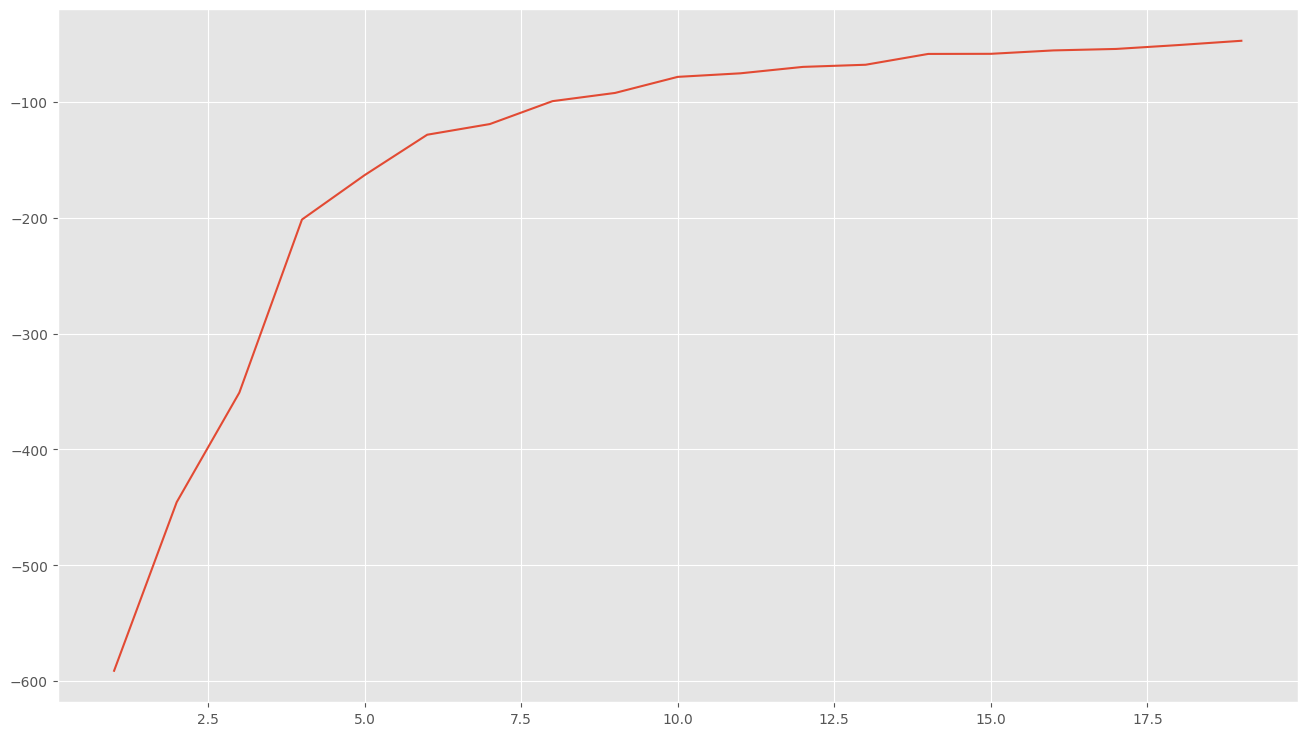

In [82]:
plt.plot(Nc, score)

## Elección de clusters

In [83]:
kmeans = KMeans(n_clusters = 7).fit(df)
centroids = kmeans.cluster_centers_
print(centroids)

[[-0.8433552  -0.13831064 -0.02024691]
 [-0.4399087   1.00734583  1.23930881]
 [ 1.24219165 -0.24104572 -0.0314837 ]
 [ 0.4704706  -1.32748824 -1.19688513]
 [-0.99375332 -1.36809664  1.06466344]
 [-0.69649208  0.92966202 -1.45442938]
 [ 0.63472128  1.11443024 -1.16777545]]


### Datos de los centroides

In [84]:
for each in centroids:
  print(each * df_std + df_mean)

Age               27.108108
Annual Income     56.297297
Spending Score    49.675676
dtype: float64
Age               32.763158
Annual Income     85.210526
Spending Score    82.105263
dtype: float64
Age               56.340909
Annual Income     53.704545
Spending Score    49.386364
dtype: float64
Age               45.523810
Annual Income     26.285714
Spending Score    19.380952
dtype: float64
Age               25.000000
Annual Income     25.260870
Spending Score    77.608696
dtype: float64
Age               29.166667
Annual Income     83.250000
Spending Score    12.750000
dtype: float64
Age               47.826087
Annual Income     87.913043
Spending Score    20.130435
dtype: float64


## Visualización en diseño 3D

In [85]:
df['Cluster_kmeans'] = kmeans.fit_predict(df[['Age', 'Annual Income', 'Spending Score']])

colores = ['blue', 'red', 'green', 'cyan', 'purple', 'yellow', 'black', 'orange']

fig = go.Figure()

for i in df['Cluster_kmeans'].unique():
  df_cluster = df[df['Cluster_kmeans'] == i]
  fig.add_trace(go.Scatter3d(
    x = df_cluster['Age'], 
    y = df_cluster['Annual Income'], 
    z = df_cluster['Spending Score'], 
    mode = 'markers',
    marker = dict(
      size = 3,
      color = colores[i],
      opacity = 0.8
    ),
    name = 'Cluster ' + str(i)
  ))

fig.show()

## Dendrogramas

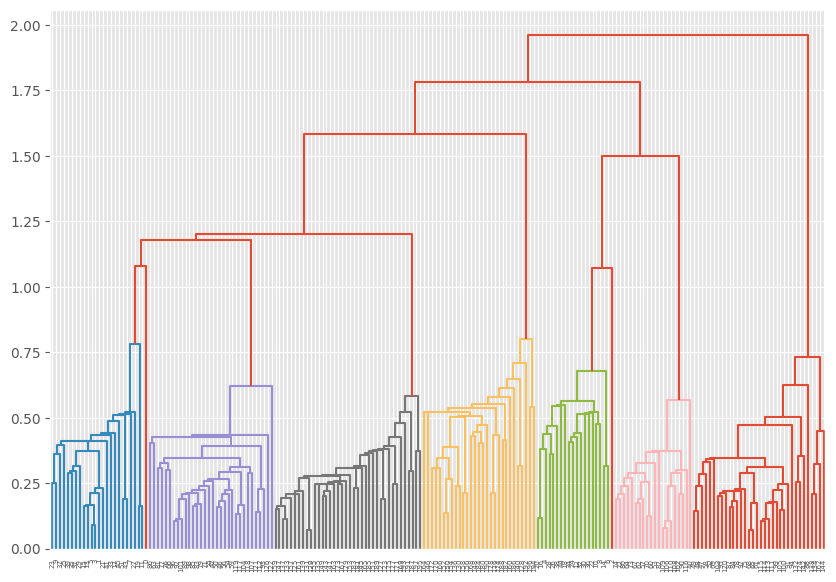

In [86]:
linked = linkage(df, 'single')

plt.figure(figsize = (10, 7))
dendrogram(linked,
           orientation = 'top',
           labels = df.index,
           distance_sort = 'descending',
           show_leaf_counts = True,
           color_threshold = 1)
plt.show()

### Calcular calidad del dendrogramas

In [87]:
c, coph_dists = cophenet(linked, pdist(df))

print(c)

0.8015544316868429


## Método Centroid

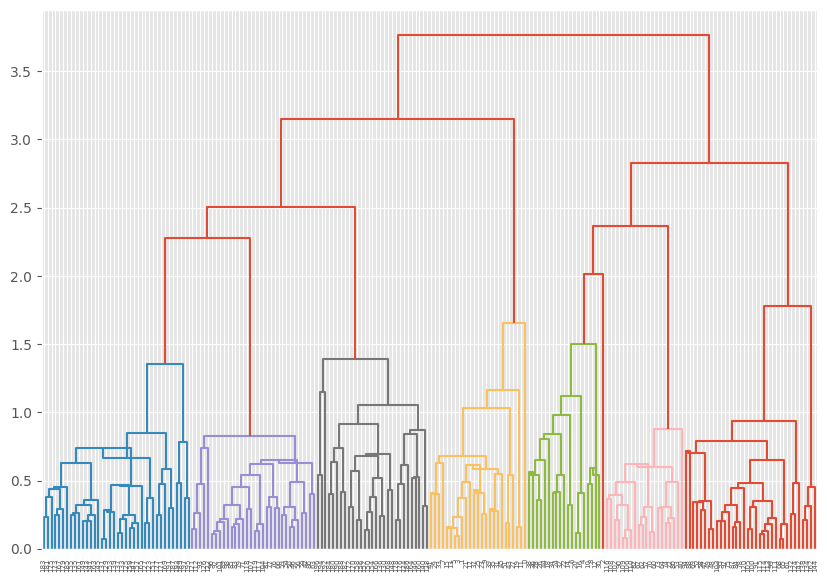

In [88]:
linked = linkage(df, 'centroid')

plt.figure(figsize = (10, 7))
dendrogram(linked,
           orientation = 'top',
           labels = df.index,
           distance_sort = 'descending',
           show_leaf_counts = True,
           color_threshold=2)
plt.show()

### Calidad del dendrogramas

In [89]:
c, coph_dists = cophenet(linked, pdist(df))
print(c)

0.8297813823903086


## Método Ward

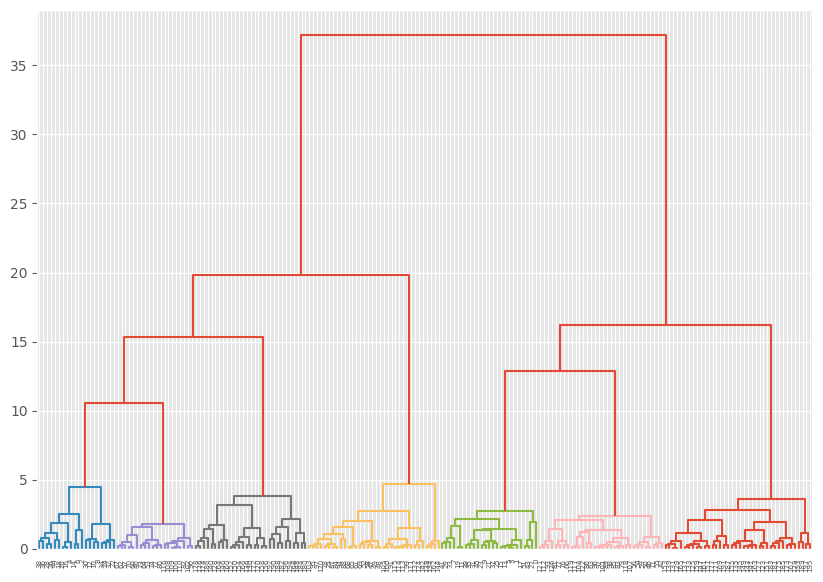

In [90]:
linked = linkage(df, 'ward')

plt.figure(figsize = (10, 7))
dendrogram(linked,
           orientation = 'top',
           labels = df.index,
           distance_sort = 'descending',
           show_leaf_counts = True,
           color_threshold=5)
plt.show()

### Calcular calidad del dendrogramas

In [91]:
c, coph_dists = cophenet(linked, pdist(df))

print(c)

0.7935014295982935


# Agrupamiento por género

## Se repite la parte de tratamiento de datos

In [92]:
df = pd.read_csv(r"mallCustomers.csv")

# Quitamos CustomerID
df = df.drop('CustomerID', axis = 1)
df.head()

,Genre,Age,Annual Income,Spending Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


### Se crea un df para cada género

In [93]:
df_female = df[df['Genre'] == 'Female']
df_female = df_female.drop('Genre', axis = 1)
df_male = df[df['Genre'] == 'Male']
df_male = df_male.drop('Genre', axis = 1)

### Se quitan outlayers

In [94]:
df_female = df_female[df_female['Annual Income'] < 135]
df_male = df_male[df_male['Annual Income'] < 135]

### Estándarización de los datos

In [95]:
df_female_mean = df_female.mean()
df_female_std = df_female.std()
df_female = (df_female - df_female_mean) / df_female_std

df_male_mean = df_male.mean()
df_male_std = df_male.std()
df_male = (df_male - df_male_mean) / df_male_std

## K-means

### Creación de clusters (female)

In [96]:
kmeans_female = KMeans(n_clusters = 6).fit(df_female)
centroids_female = kmeans_female.cluster_centers_

### Visualización de los centroides

In [97]:
for each in centroids_female:
  print(each * df_std + df_mean)

Age               24.920666
Annual Income     27.229608
Spending Score    81.171911
dtype: float64
Age               56.728068
Annual Income     54.918132
Spending Score    47.458128
dtype: float64
Age               45.234279
Annual Income     92.809935
Spending Score    17.223077
dtype: float64
Age               27.690383
Annual Income     57.954167
Spending Score    45.491970
dtype: float64
Age               42.743044
Annual Income     28.050561
Spending Score    17.275874
dtype: float64
Age               32.380158
Annual Income     85.787406
Spending Score    82.376464
dtype: float64


### Visualización en 3D (female)

In [98]:
df_female['Cluster_female'] = kmeans.fit_predict(df_female[['Age', 'Annual Income', 'Spending Score']])

colores = ['blue', 'red', 'green', 'cyan', 'purple', 'yellow', 'brown', 'orange']

fig_female = go.Figure()

for i in df_female['Cluster_female'].unique():
  df_cluster = df_female[df_female['Cluster_female'] == i]
  fig_female.add_trace(go.Scatter3d(
    x = df_cluster['Age'], 
    y = df_cluster['Annual Income'], 
    z = df_cluster['Spending Score'], 
    mode = 'markers',
    marker = dict(
      size = 3,
      color = colores[i],
      opacity = 0.8
    ),
    name = 'Cluster ' + str(i)
  ))

fig_female.add_trace(go.Scatter3d(
  x = centroids_female[:, 0], 
  y = centroids_female[:, 1], 
  z = centroids_female[:, 2], 
  mode = 'markers',
  marker = dict(
    size = 5,
    color = 'black',                
    opacity = 0.8
  ),
  name = 'Centroids'
))

fig_female.show()

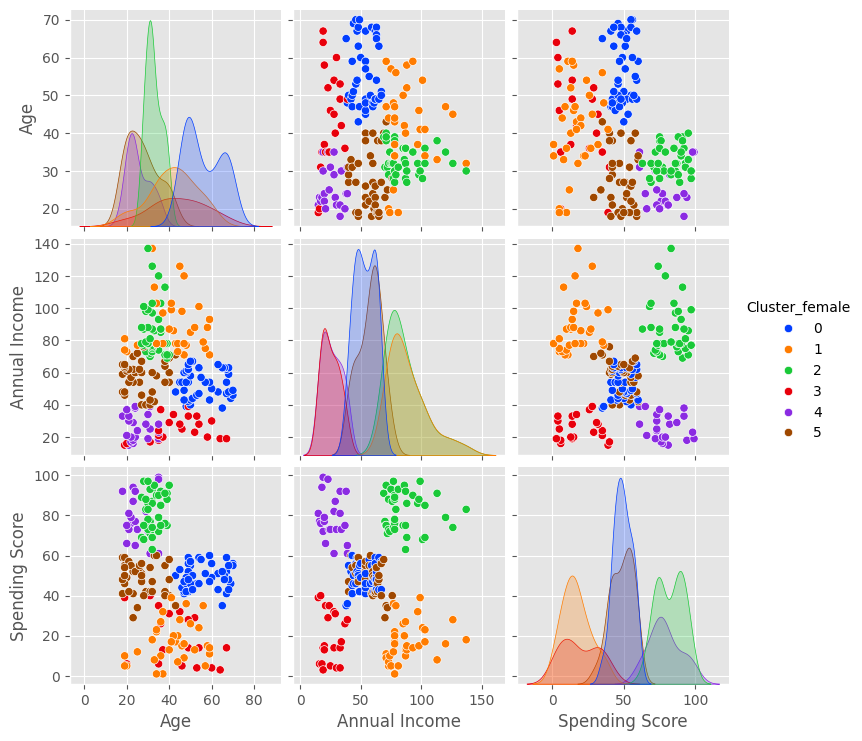

In [99]:
if 'Cluster_female' not in df.columns:
	df['Cluster_female'] = kmeans_female.fit_predict(df[['Age', 'Annual Income', 'Spending Score']])

# Mostramos todas las combinaciones de variables en 2D
sb.pairplot(df, hue='Cluster_female', diag_kind='kde', palette='bright')
plt.show()

### Creación de clusters (male)

In [100]:
kmeans_male = KMeans(n_clusters = 6).fit(df_male)
centroids_male = kmeans_male.cluster_centers_

### Visualización de los centroides

In [101]:
for each in centroids_male:
  print(each * df_std + df_mean)

Age               33.065568
Annual Income     84.364715
Spending Score    81.879997
dtype: float64
Age               56.234539
Annual Income     53.383711
Spending Score    50.887886
dtype: float64
Age               49.676288
Annual Income     23.875872
Spending Score    21.263875
dtype: float64
Age               38.824506
Annual Income     82.543436
Spending Score    18.105119
dtype: float64
Age               24.934224
Annual Income     22.656788
Spending Score    73.679714
dtype: float64
Age               25.610011
Annual Income     54.412829
Spending Score    54.400325
dtype: float64


### Visualización en 3D (male)

In [102]:
df_male['Cluster_male'] = kmeans.fit_predict(df_male[['Age', 'Annual Income', 'Spending Score']])

# Define los colores para cada cluster
colores = ['blue', 'red', 'green', 'cyan', 'purple', 'yellow', 'brown', 'orange']

fig_male = go.Figure()

# Scatter plot para cada cluster
for i in df_male['Cluster_male'].unique():
  df_cluster = df_male[df_male['Cluster_male'] == i]
  fig_male.add_trace(go.Scatter3d(
    x = df_cluster['Age'], 
    y = df_cluster['Annual Income'], 
    z = df_cluster['Spending Score'], 
    mode = 'markers',
    marker = dict(
      size = 3,
      color = colores[i],
      opacity = 0.8
    ),
    name = 'Cluster ' + str(i)
  ))

# Añade los centroides al gráfico
fig_male.add_trace(go.Scatter3d(
  x = centroids_male[:, 0], 
  y = centroids_male[:, 1], 
  z = centroids_male[:, 2], 
  mode = 'markers',
  marker = dict(
    size = 5,
    color = 'black',                
    opacity = 0.8
  ),
  name = 'Centroids'
))

fig_male.show()

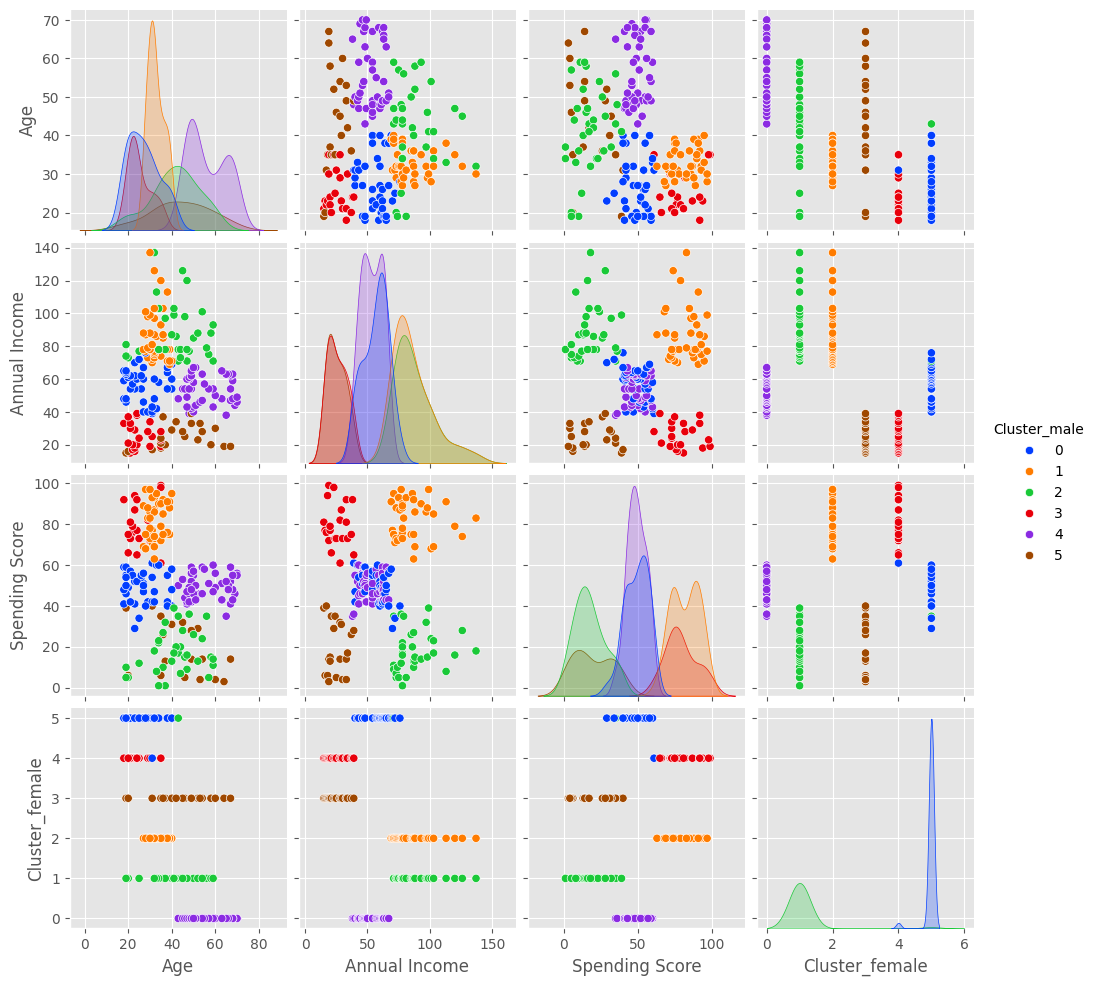

In [103]:
if 'Cluster_male' not in df.columns:
	df['Cluster_male'] = kmeans_female.fit_predict(df[['Age', 'Annual Income', 'Spending Score']])

# Mostramos todas las combinaciones de variables en 2D
sb.pairplot(df, hue='Cluster_male', diag_kind='kde', palette='bright')
plt.show()